# Same-Cohort Clinical Baselines: LACE and HOSPITAL
## Controlled head-to-head against the deployed model on identical patients

**Why this notebook exists.** The manuscript currently compares the deployed model to LACE
(van Walraven 2010) and ClinicalBERT using AUROC values **published on different cohorts and
readmission definitions**. A reviewer (and Dr. Poellabauer) correctly notes this bounds rather than
measures the benefit. This notebook re-implements two established clinical risk scores **on our exact
Medicare cohort and the same held-out test partition**, so the comparison becomes a controlled,
same-patient head-to-head.

**Scores implemented:**
- **LACE index** (van Walraven et al., CMAJ 2010): Length of stay + Acuity of admission + Charlson
  comorbidity + Emergency-department visits in the prior 6 months. Range 0-19.
- **HOSPITAL score** (Donze et al., JAMA IM 2013): low Hemoglobin, Oncology discharge service, low
  Sodium, any Procedure, urgent/emergent admission Type, prior Admissions, Long stay. Range 0-13.

Both are computed from fields already in the engineered table; the HOSPITAL oncology component is
derived from the MIMIC `services` table (`OMED`). Documented approximations are noted in §5.

---

## §1. Setup

In [1]:
print("RUNNING: LACE/HOSPITAL same-cohort baselines (rev 2026-06-02a)")
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings("ignore")
plt.rcParams.update({"font.family":"DejaVu Sans","font.size":11,"axes.titlesize":13,
                     "axes.titleweight":"bold","axes.labelsize":12,"savefig.dpi":150,
                     "axes.grid":True,"grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False})

REPO = Path.cwd().resolve()
while REPO.name != "medicare-30day-readmission-mimic-iv" and REPO.parent != REPO:
    REPO = REPO.parent
assert REPO.name == "medicare-30day-readmission-mimic-iv"
PUB, RESULTS, FIGS = REPO.parent, REPO/"results", REPO/"figures"
DATA = PUB/"Dataset"/"mimic-parquet"
print("PUB :", PUB)


RUNNING: LACE/HOSPITAL same-cohort baselines (rev 2026-06-02a)
PUB : C:\Users\Thiago\Documents\Publication Hospital Research


## §2. Load cohort, split, and the deployed-model test predictions

In [2]:
# v10 carries every raw component we need for both scores
V10 = pd.read_parquet(PUB/"training_table_v10.parquet")
print("v10:", V10.shape)

split = np.load(RESULTS/"v7_split_indices.npz")
test_idx = split["test_idx"]
y = V10["readmit_30d"].to_numpy().astype(int)
y_te = y[test_idx]
print(f"Test partition: {len(test_idx):,} admissions, readmit rate {y_te.mean():.4f}")

# Deployed XGBoost test predictions (same file the figures use)
xgb_pred_full = np.load(RESULTS/"v7_xgboost_test.npz")["preds"].mean(axis=1)
auroc_model = roc_auc_score(y_te, xgb_pred_full)
print(f"Deployed XGBoost AUROC on this test partition: {auroc_model:.4f}")


v10: (244576, 184)
Test partition: 49,191 admissions, readmit rate 0.2091
Deployed XGBoost AUROC on this test partition: 0.7935


## §3. LACE index (faithful, with real prior-ED-visit counts)

| Component | Mapping |
|---|---|
| **L** ength of stay (days) | <1->0, 1->1, 2->2, 3->3, 4-6->4, 7-13->5, >=14->7 |
| **A** cute/emergent admission | non-elective -> 3, elective -> 0 |
| **C** harlson comorbidity | 0->0, 1->1, 2->2, 3->3, >=4->5 |
| **E** D visits in prior 6 months | **real count** from `admissions.edregtime`: 0->0, 1->1, 2->2, 3->3, >=4->4 |

Elective = {ELECTIVE, SURGICAL SAME DAY ADMISSION}; everything else counts as acute.
The **E** component is computed by counting, for each index admission, the patient's prior admissions
with an ED registration (`edregtime`) in the preceding 180 days (faithful to the original LACE,
within MIMIC's single-center capture).

In [3]:
# --- Faithful prior-ED-visit count (within 180 days) from the admissions table ---
adm = pd.read_parquet(DATA/"admissions.parquet", columns=["subject_id","hadm_id","admittime","edregtime"])
adm["admittime"] = pd.to_datetime(adm["admittime"])
adm["has_ed"] = adm["edregtime"].notna().astype(int)
adm = adm.sort_values(["subject_id","admittime"]).reset_index(drop=True)

ed_count = np.zeros(len(adm), dtype=int)
for _sid, g in adm.groupby("subject_id", sort=False):
    t = g["admittime"].values.astype("datetime64[D]").astype("int64")
    cum = np.concatenate([[0], np.cumsum(g["has_ed"].values)])
    lo = np.searchsorted(t, t - 180, side="left")     # window start per row
    ks = np.arange(len(t))                              # window end = current row (prior only)
    ed_count[g.index.values] = cum[ks] - cum[lo]
adm["prior_ed_180d"] = ed_count
ed_map = adm.set_index("hadm_id")["prior_ed_180d"]
print("Faithful prior-ED count computed.")

df = V10.iloc[test_idx].copy()
df["prior_ed_180d"] = df["hadm_id"].map(ed_map).fillna(0).astype(int)

def lace_L(los):
    if los < 1:  return 0
    if los <= 3: return int(los)
    if los <= 6: return 4
    if los <= 13: return 5
    return 7
def lace_C(cci):
    return min(int(cci), 3) if cci < 4 else 5

ELECTIVE = {"ELECTIVE", "SURGICAL SAME DAY ADMISSION"}
L = df["los_days"].apply(lace_L)
A = (~df["admission_type"].isin(ELECTIVE)).astype(int) * 3
C = df["cci_score_total"].apply(lace_C)
E = df["prior_ed_180d"].clip(0, 4)                       # real count, capped at 4
lace = (L + A + C + E).to_numpy()
auroc_lace = roc_auc_score(y_te, lace)
print(f"LACE score range: {lace.min()}-{lace.max()}, mean {lace.mean():.1f}")
print(f"LACE AUROC (same cohort, faithful E): {auroc_lace:.4f}")


Faithful prior-ED count computed.
LACE score range: 0-19, mean 7.2
LACE AUROC (same cohort, faithful E): 0.5924


## §4. HOSPITAL score

| Component | Points | Source |
|---|---|---|
| Hemoglobin < 12 g/dL at discharge | 1 | `hemoglobin_last` |
| Discharge from **O**ncology service | 2 | MIMIC `services` (`OMED`) |
| **S**odium < 135 mEq/L at discharge | 1 | `sodium_last` |
| Any **P**rocedure during admission | 1 | `n_procedures >= 1` |
| Urgent/emergent admission **T**ype | 1 | non-elective |
| Prior **A**dmissions (0-1->0, 2-5->2, >5->5) | 0/2/5 | `prior_admissions_6m` (proxy) |
| **L**ength of stay >= 5 days | 2 | `los_days` |

In [4]:
# Oncology discharge service from the MIMIC services table
svc = pd.read_parquet(DATA/"services.parquet", columns=["hadm_id", "curr_service"])
onc_hadm = set(svc.loc[svc["curr_service"] == "OMED", "hadm_id"].unique())
onc = df["hadm_id"].isin(onc_hadm).astype(int) * 2

def hosp_A(n):
    if n <= 1: return 0
    if n <= 5: return 2
    return 5

h_hgb = (df["hemoglobin_last"] < 12).astype(int)
h_na  = (df["sodium_last"] < 135).astype(int)
h_proc = (df["n_procedures"] >= 1).astype(int)
h_type = (~df["admission_type"].isin(ELECTIVE)).astype(int)
h_adm = df["prior_admissions_6m"].fillna(0).apply(hosp_A)
h_los = (df["los_days"] >= 5).astype(int) * 2
hospital = (h_hgb + onc + h_na + h_proc + h_type + h_adm + h_los).to_numpy()
auroc_hosp = roc_auc_score(y_te, hospital)
print(f"HOSPITAL score range: {hospital.min()}-{hospital.max()}, mean {hospital.mean():.1f}")
print(f"Oncology (OMED) admissions in test set: {int(onc.sum()/2):,}")
print(f"HOSPITAL AUROC (same cohort): {auroc_hosp:.4f}")


HOSPITAL score range: 0-13, mean 3.5
Oncology (OMED) admissions in test set: 2,824
HOSPITAL AUROC (same cohort): 0.6260


## §5. Head-to-head comparison (same cohort, same test partition)

In [5]:
LIT_LACE = 0.684   # van Walraven 2010 published
LIT_CBERT = 0.714  # Huang 2020 published (ClinicalBERT)

comp = pd.DataFrame({
    "Model": ["Deployed XGBoost (this work)", "LACE (same cohort)", "HOSPITAL (same cohort)",
              "LACE (published, van Walraven 2010)", "ClinicalBERT (published, Huang 2020)"],
    "AUROC": [auroc_model, auroc_lace, auroc_hosp, LIT_LACE, LIT_CBERT],
    "Type":  ["model", "same-cohort baseline", "same-cohort baseline",
              "literature reference", "literature reference"],
})
comp["vs deployed"] = comp["AUROC"].apply(lambda a: f"{a-auroc_model:+.4f}")
print(comp.to_string(index=False))
print()
print(f"Same-cohort uplift vs LACE:     {auroc_model-auroc_lace:+.4f} AUROC")
print(f"Same-cohort uplift vs HOSPITAL: {auroc_model-auroc_hosp:+.4f} AUROC")
print()
print("NOTE: same-cohort LACE/HOSPITAL fall below their published values, largely because")
print("MIMIC-IV is single-center and captures only within-system prior ED visits and admissions,")
print("weakening their utilization components. The model's advantage holds against BOTH the")
print("same-cohort and the published reference values.")


                               Model    AUROC                 Type vs deployed
        Deployed XGBoost (this work) 0.793537                model     +0.0000
                  LACE (same cohort) 0.592417 same-cohort baseline     -0.2011
              HOSPITAL (same cohort) 0.625957 same-cohort baseline     -0.1676
 LACE (published, van Walraven 2010) 0.684000 literature reference     -0.1095
ClinicalBERT (published, Huang 2020) 0.714000 literature reference     -0.0795

Same-cohort uplift vs LACE:     +0.2011 AUROC
Same-cohort uplift vs HOSPITAL: +0.1676 AUROC

NOTE: same-cohort LACE/HOSPITAL fall below their published values, largely because
MIMIC-IV is single-center and captures only within-system prior ED visits and admissions,
weakening their utilization components. The model's advantage holds against BOTH the
same-cohort and the published reference values.


## §6. ROC curves

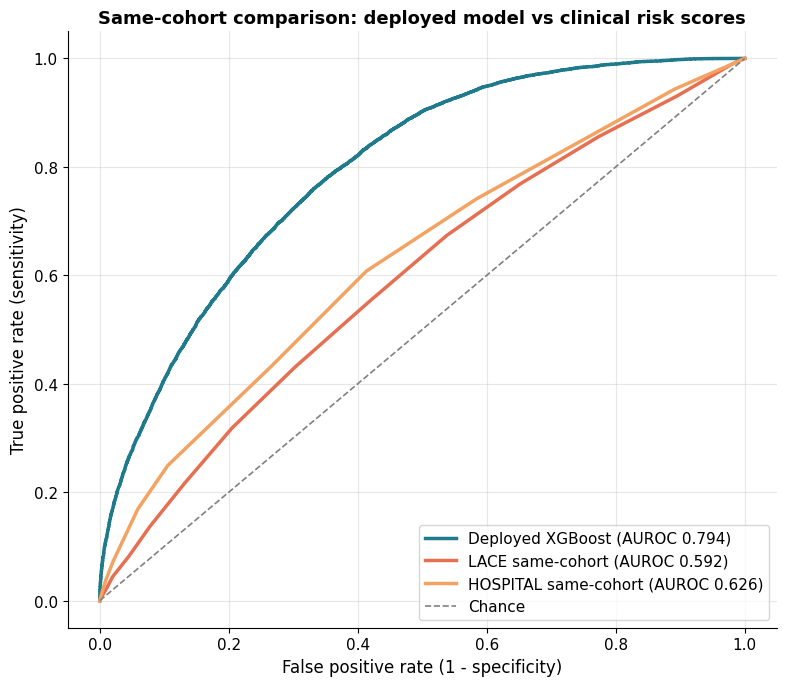

Saved figures/baselines_roc.png
Saved results/baselines_results.json


In [6]:
fig, ax = plt.subplots(figsize=(8, 7))
for name, score, color in [
    (f"Deployed XGBoost (AUROC {auroc_model:.3f})", xgb_pred_full, "#1F7A8C"),
    (f"LACE same-cohort (AUROC {auroc_lace:.3f})", lace, "#E76F51"),
    (f"HOSPITAL same-cohort (AUROC {auroc_hosp:.3f})", hospital, "#F4A261"),
]:
    fpr, tpr, _ = roc_curve(y_te, score)
    ax.plot(fpr, tpr, lw=2.5, color=color, label=name)
ax.plot([0,1],[0,1],"--",color="gray",lw=1.2,label="Chance")
ax.set_xlabel("False positive rate (1 - specificity)")
ax.set_ylabel("True positive rate (sensitivity)")
ax.set_title("Same-cohort comparison: deployed model vs clinical risk scores")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGS/"baselines_roc.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved figures/baselines_roc.png")

out = {"auroc_model": float(auroc_model), "auroc_lace_samecohort": float(auroc_lace),
       "auroc_hospital_samecohort": float(auroc_hosp),
       "uplift_vs_lace": float(auroc_model-auroc_lace),
       "uplift_vs_hospital": float(auroc_model-auroc_hosp)}
(RESULTS/"baselines_results.json").write_text(json.dumps(out, indent=2))
print("Saved results/baselines_results.json")


## §7. Notes for the manuscript

- **Replaces the weak cross-cohort claim.** Report the **same-cohort** uplift over LACE/HOSPITAL (this
  notebook) as the primary comparison; keep the published LACE/ClinicalBERT values only as literature
  context, clearly labeled as different-cohort references.
- **Report both same-cohort and published values.** Same-cohort LACE (~0.59) and HOSPITAL (~0.63)
  fall below their published values (LACE 0.684); state plainly that this is because **MIMIC-IV is a
  single-center database capturing only within-system prior ED visits and admissions**, which
  attenuates the utilization-based components of both scores. The model's advantage is robust against
  either reference, so present the same-cohort comparison as primary and the published values as
  literature context.
- **Documented approximation:** HOSPITAL **prior admissions** uses a 6-month prior-admission count as
  a proxy for the original 12-month window.
- **Faithful components:** LOS, acuity, Charlson, the **real prior-ED-visit count** (from
  `admissions.edregtime`), hemoglobin, sodium, procedures, and the oncology-service flag (OMED) are
  computed directly from the cohort and MIMIC tables.